In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R


In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
from os import path
import matplotlib.pyplot as plt
import numpy as np

DATA_COLUMNS = ['AccX', 'AccY', 'AccZ', 'VelX', 'VelY', 'VelZ', 'PosX', 'PosY', 'PosZ', 'Pitch', 'Roll', 'Yaw']

In [107]:
from utils import load_airtable_data, load_config, load_mongo_data

#data = load_airtable_data()
data = load_mongo_data()
config = load_config()
data.head()

,_id,Exercise_id,Counter,TimeBetweenSamples,AccX,AccY,AccZ,Pitch,Roll,Yaw,...,User_id,Date,WorkoutTime,HeartRate,EndRepTime,StartRepTime,Intensity,Reps,Weight,Notes
0,66f8a0facfd19a2dbc3643b7,AD7CECF3-FB0B-4CDD-9C74-35F26FE1C1EA,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[15318, 10, 10, 10, 10, 10, 10, 10, 10, 11, 9,...","[-0.004, -0.049, -0.07, -0.051, -0.004, 0.023,...","[0.046, -0.009, 0.023, -0.019, -0.02, -0.016, ...","[-0.038, -0.014, 0.016, 0.034, 0.026, 0.075, 0...","[0.671, 0.67, 0.669, 0.667, 0.665, 0.664, 0.66...","[-0.017, -0.017, -0.018, -0.017, -0.016, -0.01...","[0.006, 0.007, 0.007, 0.007, 0.006, 0.006, 0.0...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:36:08,34.11,"[95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 9...",31.30,5.13,NaN,NaN,NaN,NaN
1,66f8a1d9cfd19a2dbc3643bf,255F3E86-9C12-4CC0-A503-E65F058E5711,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[195017, 10, 11, 21, 0, 9, 10, 10, 10, 10, 10,...","[-0.226, -0.295, 0.029, 0.275, 0.151, -0.101, ...","[0.095, 0.135, 0.18, 0.186, 0.154, 0.197, 0.18...","[0.019, 0.012, -0.064, -0.194, -0.222, -0.203,...","[0.615, 0.613, 0.612, 0.61, 0.609, 0.608, 0.60...","[-0.182, -0.182, -0.183, -0.185, -0.187, -0.18...","[0.058, 0.059, 0.06, 0.062, 0.064, 0.064, 0.06...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:39:52,29.15,"[102, 102, 102, 102, 102, 102, 102, 102, 102, ...",24.72,5.47,NaN,NaN,NaN,NaN
2,66f8a2eacfd19a2dbc3643c7,F4B75458-7440-4484-88FD-ADCF4C4F34B4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[244750, 10, 10, 12, 8, 10, 11, 9, 10, 9, 10, ...","[-0.454, -0.14, 0.206, 0.17, 0.146, 0.099, 0.0...","[-0.321, -0.291, -0.243, -0.207, -0.032, 0.17,...","[0.162, 0.112, 0.026, 0.013, -0.063, -0.043, -...","[0.537, 0.534, 0.531, 0.528, 0.526, 0.525, 0.5...","[-0.199, -0.199, -0.199, -0.201, -0.201, -0.20...","[0.055, 0.054, 0.053, 0.052, 0.051, 0.05, 0.04...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:44:25,27.75,"[92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 9...",22.62,6.03,NaN,NaN,NaN,NaN
3,66f8a39ccfd19a2dbc3643cf,98650F9A-F356-4563-9A0E-26FFB73C4D77,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[146117, 10, 10, 10, 10, 10, 12, 9, 10, 10, 10...","[-0.25, 0.027, 0.239, 0.229, 0.186, 0.156, 0.1...","[-0.278, -0.131, 0.076, 0.191, 0.213, 0.18, 0....","[-0.097, -0.134, -0.208, -0.209, -0.182, -0.07...","[0.452, 0.45, 0.449, 0.447, 0.446, 0.445, 0.44...","[-0.018, -0.02, -0.02, -0.02, -0.02, -0.019, -...","[0.004, 0.005, 0.005, 0.005, 0.004, 0.003, 0.0...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:47:22,30.76,"[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",26.85,12.97,NaN,NaN,NaN,NaN
4,66f8a43ecfd19a2dbc3643d7,CEE08F0F-C418-4B32-88FE-81D6EB5ECC2B,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[122958, 10, 10, 10, 12, 8, 10, 10, 10, 11, 9,...","[0.053, 0.1, 0.188, 0.258, 0.248, 0.13, 0.027,...","[0.116, 0.012, 0.176, 0.226, 0.223, 0.21, 0.12...","[-0.122, -0.151, -0.216, -0.211, -0.13, -0.003...","[0.271, 0.268, 0.268, 0.269, 0.271, 0.273, 0.2...","[0.054, 0.054, 0.052, 0.05, 0.05, 0.05, 0.05, ...","[-0.007, -0.006, -0.004, -0.002, 0.0, 0.001, 0...",...,001325.0c0b48026b9148b781a1435ef3ae2188.0505,2024-09-29 00:50:04,39.11,"[91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 9...",33.16,16.02,NaN,NaN,NaN,NaN


Actual: DB Bench


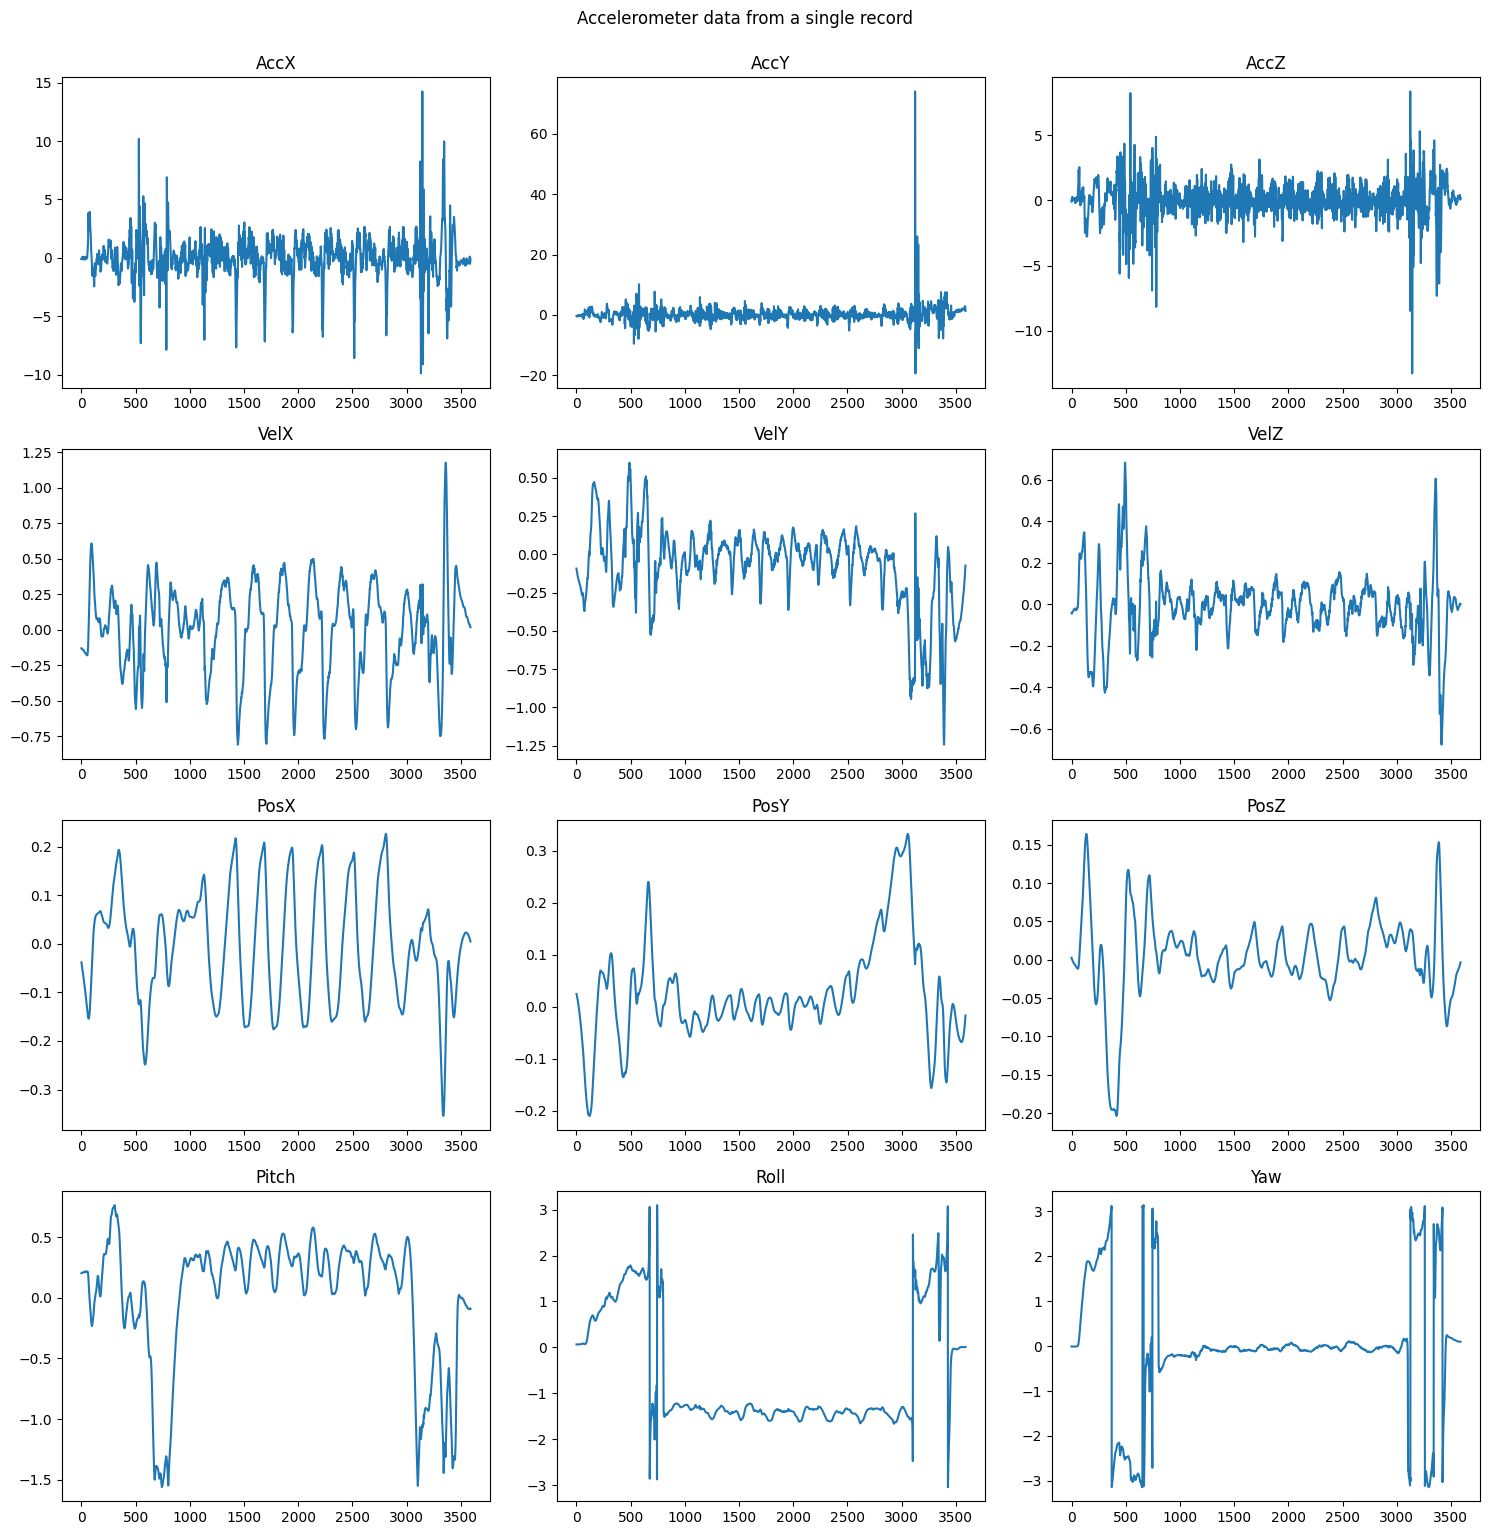

In [108]:

from preprocessing import preprocess_data, extract_features

exercise_id = '0A8E4BB2-9DAE-4493-83D2-D917B9AA0EFC'
record = data[data['Exercise_id'] == exercise_id]

record = record.sample(1)

if record.empty:
    raise ValueError(f"No record found with Exercise_id: {exercise_id}")

record = preprocess_data(record, config['CutoffFreq'], config['SampleRate'])

print(f"Actual: {record['Exercise'].values[0]}")

fig, axs = plt.subplots(4, 3, figsize=(15, 15))

for i, ax in enumerate(axs.flat):
    plot_data = np.concatenate(record[DATA_COLUMNS[i]].to_numpy())
    ax.plot(plot_data)
    ax.set_title(DATA_COLUMNS[i])

plt.tight_layout()
plt.suptitle('Accelerometer data from a single record', y=1.02)
plt.show()

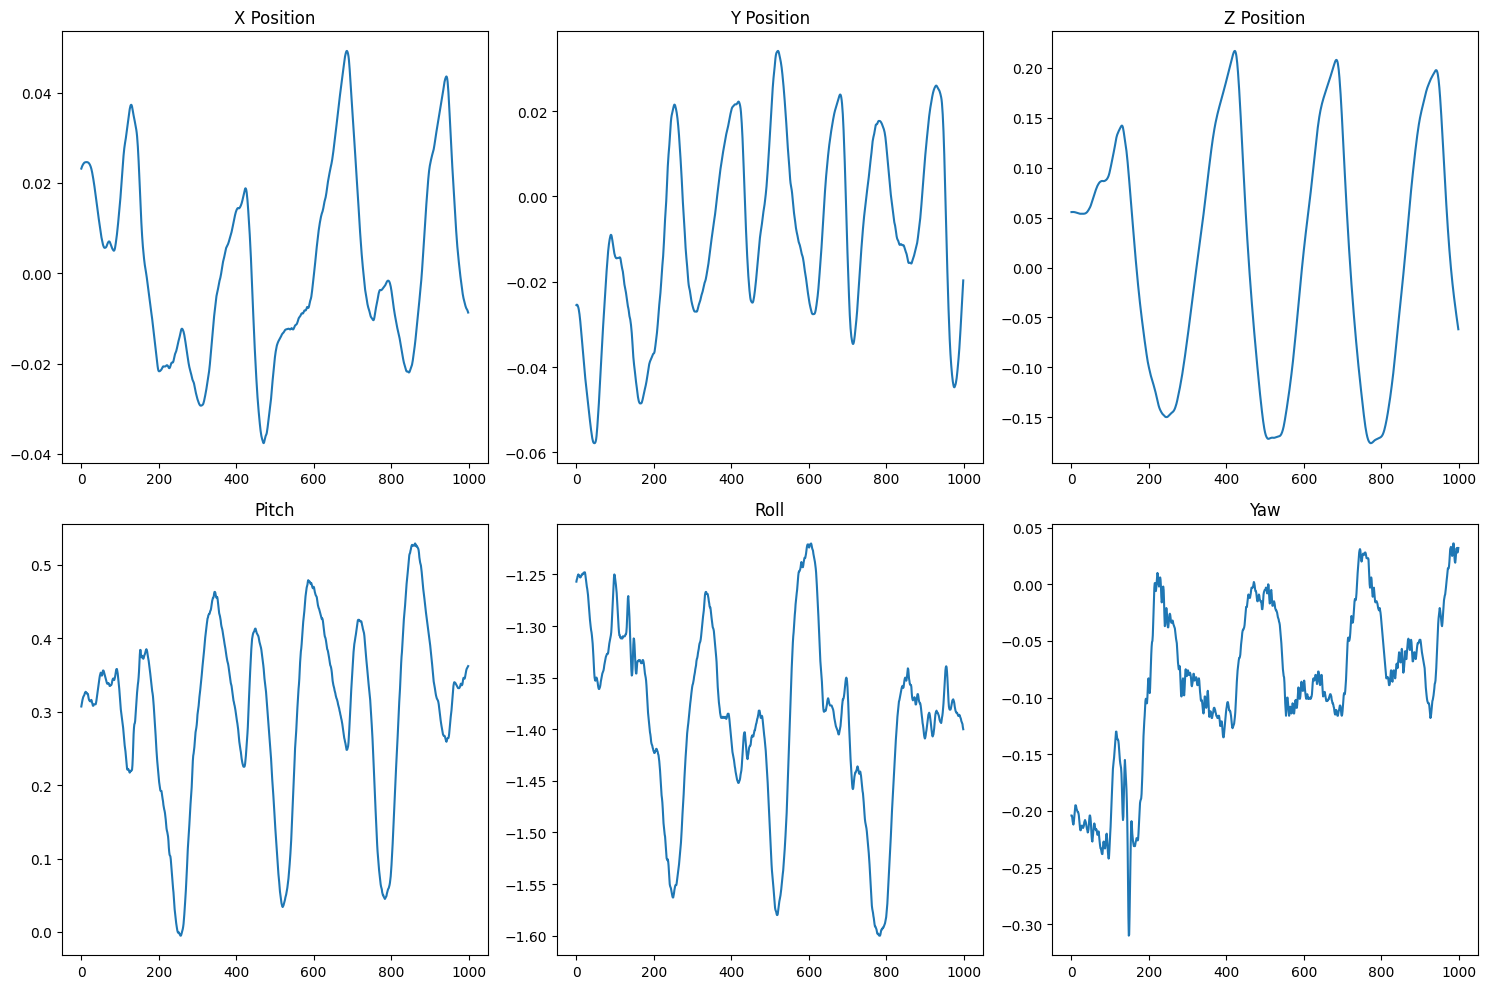

In [113]:
# Example data for bench press movement
time_steps = 600
start = 1000
end = 2000
z = np.concatenate(record[DATA_COLUMNS[6]].to_numpy())[start:end]
y = np.concatenate(record[DATA_COLUMNS[7]].to_numpy())[start:end]
x = np.concatenate(record[DATA_COLUMNS[8]].to_numpy())[start:end]
pitch = np.concatenate(record[DATA_COLUMNS[9]].to_numpy())[start:end]
roll = np.concatenate(record[DATA_COLUMNS[10]].to_numpy())[start:end]
yaw = np.concatenate(record[DATA_COLUMNS[11]].to_numpy())[start:end]


# Plotting the X, Y, Z, Pitch, Roll, Yaw data
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].plot(x)
axs[0, 0].set_title('X Position')
axs[0, 1].plot(y)
axs[0, 1].set_title('Y Position')
axs[0, 2].plot(z)
axs[0, 2].set_title('Z Position')
axs[1, 0].plot(pitch)
axs[1, 0].set_title('Pitch')
axs[1, 1].plot(roll)
axs[1, 1].set_title('Roll')
axs[1, 2].plot(yaw)
axs[1, 2].set_title('Yaw')
plt.tight_layout()
plt.show()

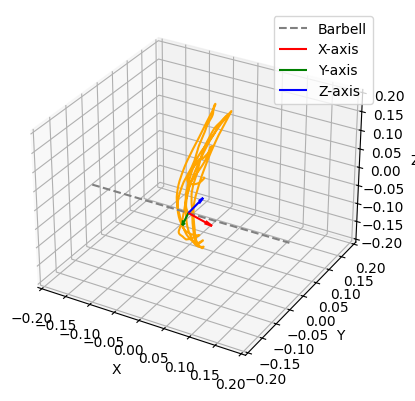

In [114]:
def update(num, data, line, quiver, ax):
    ax.clear()
    ax.set_xlim(-0.2, 0.2)
    ax.set_ylim(-0.2, 0.2)
    ax.set_zlim(-0.2, 0.2)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Update position
    line.set_data(data[:2, :num])
    line.set_3d_properties(data[2, :num])
    ax.plot3D(data[0, :num], data[1, :num], data[2, :num], color='orange')

    # Add a moving barbell line centered at the quiver's origin
    origin = [x[num], y[num], z[num]]
    bar_x = np.linspace(origin[0] - 0.2, origin[0] + 0.2, 10)
    bar_y = np.full(10, origin[1])
    bar_z = np.full(10, origin[2])
    ax.plot(bar_x, bar_y, bar_z, color='grey', linestyle='--', label='Barbell')

    # Update orientation with arrows
    current_rotation = R.from_euler('xyz', [roll[num], pitch[num], yaw[num]])
    orientation_vectors = current_rotation.apply(np.eye(3))  # Get basis vectors

    ax.quiver(*origin, *orientation_vectors[0], length=0.05, color='r', label='X-axis')  # X-axis
    ax.quiver(*origin, *orientation_vectors[1], length=0.05, color='g', label='Y-axis')  # Y-axis
    ax.quiver(*origin, *orientation_vectors[2], length=0.05, color='b', label='Z-axis')  # Z-axis

    # Add legend
    ax.legend()

    return line, quiver

# Prepare figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-0.2, 0.2)
ax.set_ylim(-0.2, 0.2)
ax.set_zlim(-0.2, 0.2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Data setup
data = np.array([x, y, z])

# Initialize line and quiver for animation
line, = ax.plot([], [], [], lw=2)
quiver = None  # Will be updated in the update function
ani = FuncAnimation(fig, update, frames=range(0, len(x), 5), fargs=(data, line, quiver, ax), interval=50)

# Save the animation as a file
ani.save('3d_animation.gif', writer=PillowWriter(fps=20))

plt.show()